# Dangerous Accessible Space / Expected Pass Completion

<b>Dangerous accessible space (DAS)</b> is a flavor of EPV (expected possession value) based on <b>physical pass simulations</b>. For every frame where a player is in possession, the model simulates multiple ground passes of that player with different speeds and angles, such that all possible directions are covered. Then it calculates the likelihood that each player can intercept a given pass at every position along its simulated trajectory. This likelihood can then be weighted by some measure of goal threat, aggregated by team, and integrated across the pitch to give a numerical value, describing the amount of dangerous space that is accessible in the current situation.

The formula to calculate the probability to intercept or receive the ball along a pass trajectory for a given player $r$ boils down to:

$$\frac{dP_r(t)}{dt} = P_0(t)a_r(t)$$

Where $\frac{dP_r(t)}{dt}$ is the probability density that player $r$ intercepts the ball at time $t$ along the pass trajectory, $P_0(t)$ is the probability that the ball has not been intercepted yet until time $t$ and $a_r(t)$ is the transition rate from $P_0(t)$ (not intercepted) to $P_r(t)$ (intercepted by $r$). The calculation of $a_r(t)$ is based on the difference between the arrival time of a player and the ball like this:

$$a_r(t) = \frac{1}{1 + e^{b_0 + b_1(T_r(t) - t)}}\frac{1}{\sigma(v_B(t))}$$

Where $b_0$ and $b_1$ are parameters, $T_r(t)$ is the arrival time of the player, $t$ is the arrival time of the ball and $\sigma(v_B(t))$ is a function that gives the model an additional factor that is dependent on the ball speed $v_B(t)$ to take into account that the ability to intercept varies with the speed of the ball. Essentially, this means that the earlier a player arrives relative the ball, the higher the transition rate $a_r(t)$ (and, accordingly, the interception probability density $\frac{dP_r(t)}{dt}$).

The other half of the formula, $P_0(t)$, is calculated based on the integral of the transition rates of all players up until time $t$. Intuitively, if a lot of players had high interception rates in the past, $P_0(t)$ will be small and diminish all $\frac{dP_r(t)}{dt}$ values further down the trajectory. In other words, the likelihood of interception is low if the pass has likely been intercepted before, even if the current interception rate is high. 

$$P_0(t) = e^{\int_{0}^{t}(-\sum_{r \in R}^{}a_r(\tau))d\tau}$$

By aggregating and plotting the resulting interception probability densities $\frac{dP_r(t)}{dt}$ spatially, we obtain the <b>accessible space</b> field (left image) of a team. If we add a notion of value like Expected Goals we obtain <b>dangerous accessible space</b> (right image) whose area integral serves as our final metric, DAS.

<table>
  <tr>
    <td style="text-align: center;">
        <img src="../static/accessible_space.png">
      <p style="text-align: center;">Accessible space</p>
    </td>
    <td style="text-align: center;">
        <img src="../static/dangerous_accessible_space.png">
      <p style="text-align: center;">Dangerous accessible space</p>
    </td>
  </tr>
</table>

This is the gist of DAS and the physical pass simulations behind it. More details and explanations can be found in the publication of the model by Bischofberger and Baca (2025)$^1$ and the corresponding repository$^2$.

In databallpy, we can use the ``add_dangerous_accessible_space`` function to access team-level DAS for every frame of tracking data.

---

$^1$ Bischofberger, J., & Baca, A. (2025). Dangerous accessible space: A unified model of space and value in team sports [Preprint]. Research Square. https://doi.org/10.21203/rs.3.rs-6932689/v1

$^2$ https://github.com/jonas-bischofberger/accessible-space

In [1]:
from databallpy import get_open_match

game = get_open_match(provider="metrica")
game.tracking_data.add_dangerous_accessible_space()  # Expensive for a whole match - use parameter 'mask' to limit calculation time
game.tracking_data[
    ["period_id", "frame", "team_in_possession", "dangerous_accessible_space"]
].dropna()

Simulating passes: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 308/308 [56:23<00:00, 10.98s/chunk]


,period_id,frame,team_in_possession,dangerous_accessible_space
365,1,366,home,0.137264
366,1,367,home,0.135954
367,1,368,home,0.135291
368,1,369,home,0.135532
369,1,370,home,0.135628
...,...,...,...,...
143547,2,143548,away,0.013250
143548,2,143549,away,0.014254
143549,2,143550,away,0.014379
143550,2,143551,away,0.014622


Plotting DAS of both teams in a line graph highlights how the possession phases of the teams unfold during the game.

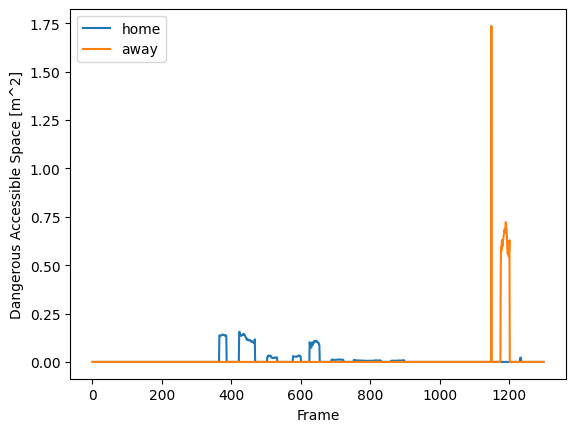

In [2]:
import matplotlib.pyplot as plt

df = game.tracking_data[game.tracking_data["frame"] < 1300].copy()  # Example slice

plt.figure()
plt.xlabel("Frame")
plt.ylabel("Dangerous Accessible Space [m^2]")
for team in game.tracking_data["team_in_possession"].dropna().unique():
    dfx = df.copy()
    i_team_possession = dfx["team_in_possession"] == team
    dfx.loc[~i_team_possession, "dangerous_accessible_space"] = (
        0.0  # set DAS to 0 while the opponent or no one controls the ball
    )
    plt.plot(dfx["frame"], dfx["dangerous_accessible_space"], label=f"{team}")

plt.legend()
plt.show()

The plot shows a relatively harmless attack by the home team in the beginning, followed by a short period of danger from the away team, possibly through a ball win or a set piece.

Aggregated DAS for each team gives us a summary of their threat during the match. In the table, we can see that the home team had higher total DAS values while the away team had higher DAS values on average, pointing to a style of play more focused on counterattacking or set pieces.

In [3]:
dfg = game.tracking_data.groupby("team_in_possession").agg(
    total_das=("dangerous_accessible_space", "sum"),
    max_das=("dangerous_accessible_space", "max"),
    mean_das=("dangerous_accessible_space", "mean"),
)
dfg["total_das"] /= (
    game.tracking_data.frame_rate
)  # divide by frame rate as normalization
dfg

,total_das,max_das,mean_das
team_in_possession,,,
away,1267.419686,36.038902,1.488350
home,1401.690163,46.576836,1.414763


Internally, ``databallpy`` calls functions from the ``accessible-space`` package. That package supports additional analyses, for example, you can obtain player-level DAS values as follows:

In [4]:
import accessible_space

df_long = game.tracking_data[game.tracking_data["frame"] < 1300].to_long_format()
df_long["team"] = df_long["column_id"].str[:4]

res = accessible_space.get_individual_dangerous_accessible_space(
    df_long,
    frame_col="frame",
    period_col="period_id",
    player_col="column_id",
    team_col="team",
    x_col="x",
    y_col="y",
    vx_col="vx",
    vy_col="vy",
    team_in_possession_col="team_in_possession",
    player_in_possession_col="player_possession",
)
df_long["AS_player"] = res.player_acc_space
df_long["DAS_player"] = res.player_das
df_long[
    ["frame", "column_id", "team", "team_in_possession", "AS_player", "DAS_player"]
].dropna().drop_duplicates().head(20)

Simulating passes: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:27<00:00,  9.16s/chunk]


,frame,column_id,team,team_in_possession,AS_player,DAS_player
1664,366,home_11,home,home,1923.803828,0.006026
1665,367,home_11,home,home,1919.857537,0.005966
1666,368,home_11,home,home,1919.200618,0.005968
1667,369,home_11,home,home,1915.738439,0.005918
1668,370,home_11,home,home,1914.047778,0.005892
1669,371,home_11,home,home,1911.291920,0.005860
1670,372,home_11,home,home,1905.833896,0.005785
1671,373,home_11,home,home,1896.090445,0.005645
1672,374,home_11,home,home,1891.421664,0.005568
1673,375,home_11,home,home,1888.834073,0.005542


DAS can be visualized using the ``plot_expected_completion_surface`` function

Simulating passes: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.58chunk/s]


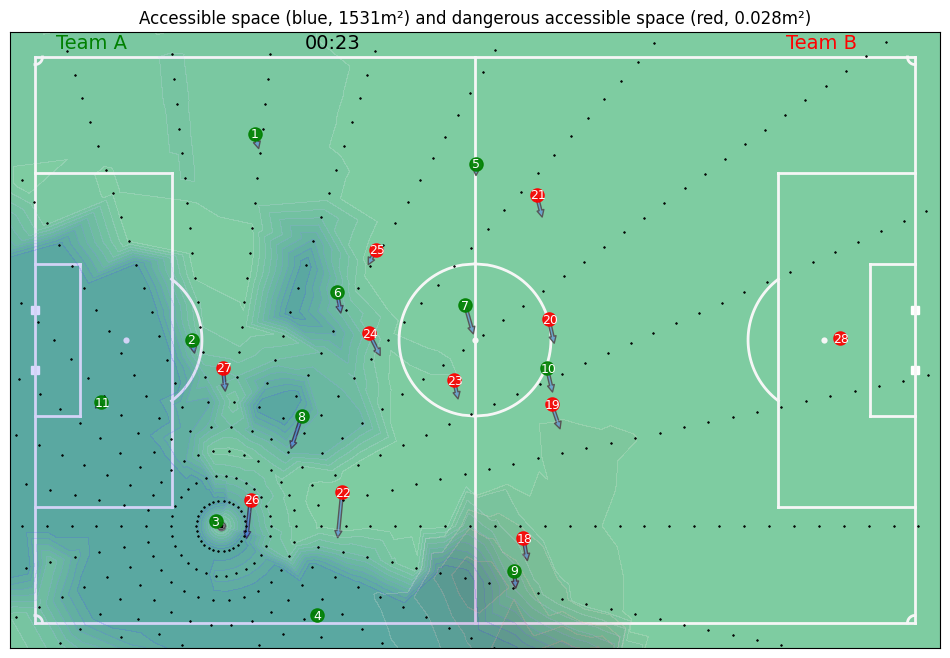

In [5]:
from databallpy.visualize import plot_soccer_pitch, plot_tracking_data

frame_to_plot = 600

df_tracking_frame = df_long[df_long["frame"] == frame_to_plot]

das = accessible_space.get_dangerous_accessible_space(
    df_tracking_frame,
    frame_col="frame",
    period_col="period_id",
    player_col="column_id",
    team_col="team",
    x_col="x",
    y_col="y",
    vx_col="vx",
    vy_col="vy",
    team_in_possession_col="team_in_possession",
    player_in_possession_col="player_possession",
)

fig, ax = plot_soccer_pitch()
fig, ax = plot_tracking_data(
    game,
    game.tracking_data[game.tracking_data["frame"] == frame_to_plot].index[0],
    fig=fig,
    ax=ax,
    title=f"Accessible space (blue, {das.acc_space.iloc[0]:.0f}m²) and dangerous accessible space (red, {das.das.iloc[0]:.3f}m²)",
    add_velocities=True,
)

fig = accessible_space.plot_expected_completion_surface(
    das.simulation_result,  # AS
    frame_index=0,
    color="blue",
)
fig = accessible_space.plot_expected_completion_surface(
    das.dangerous_result,  # DAS
    frame_index=0,
    color="red",
)

See the Github repository of ``accessible-space`` for more details and functionality.$^2$